In [1]:
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
import pandas as pd
import seaborn as sns
import random
import math
import numpy as np
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets

In [2]:
penguins = load_penguins()
penguins_original = pd.DataFrame(penguins)
data = penguins_original

features = data[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm', 'body_mass_g']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

penguins_original[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm', 'body_mass_g']] = features_scaled
data[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm', 'body_mass_g']] = features_scaled

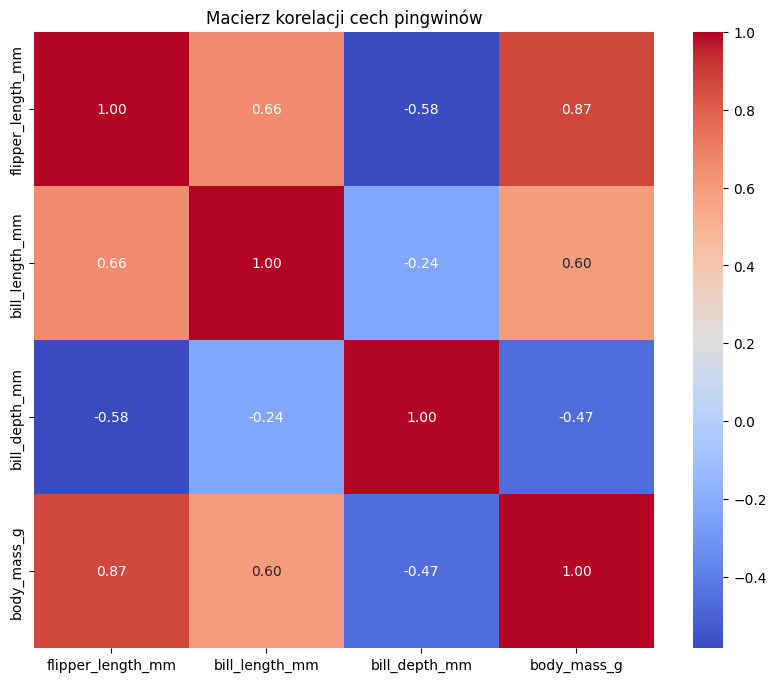

In [3]:
corr_matrix = penguins_original[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm', 'body_mass_g']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji cech pingwinów")
plt.show()

Korelacja między body_mass a flipper_length = 0.87 jest znacząca. Przetestuje algorytm dla 3 cech a później dla 4 z uwzględnieniem masy

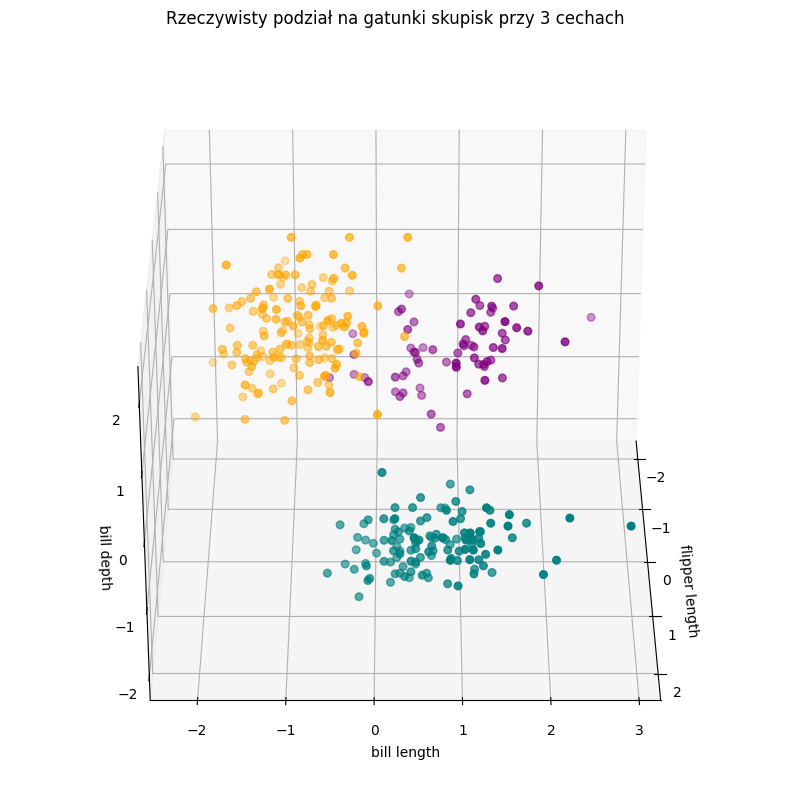

In [4]:
colors = {'Adelie': 'orange', 'Chinstrap': 'purple', 'Gentoo': 'teal'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data['flipper_length_mm'], 
    data['bill_length_mm'], 
    data['bill_depth_mm'], 
    c=data['species'].map(colors), 
    s=30
)
ax.set_xlabel("flipper length")
ax.set_ylabel("bill length")
ax.set_zlabel("bill depth", labelpad=0)

ax.view_init(elev=30,azim=0)

plt.title("Rzeczywisty podział na gatunki skupisk przy 3 cechach")
plt.show()

TEST dla 3 cech bez masy bo jest silnie scorelowana z flipper length

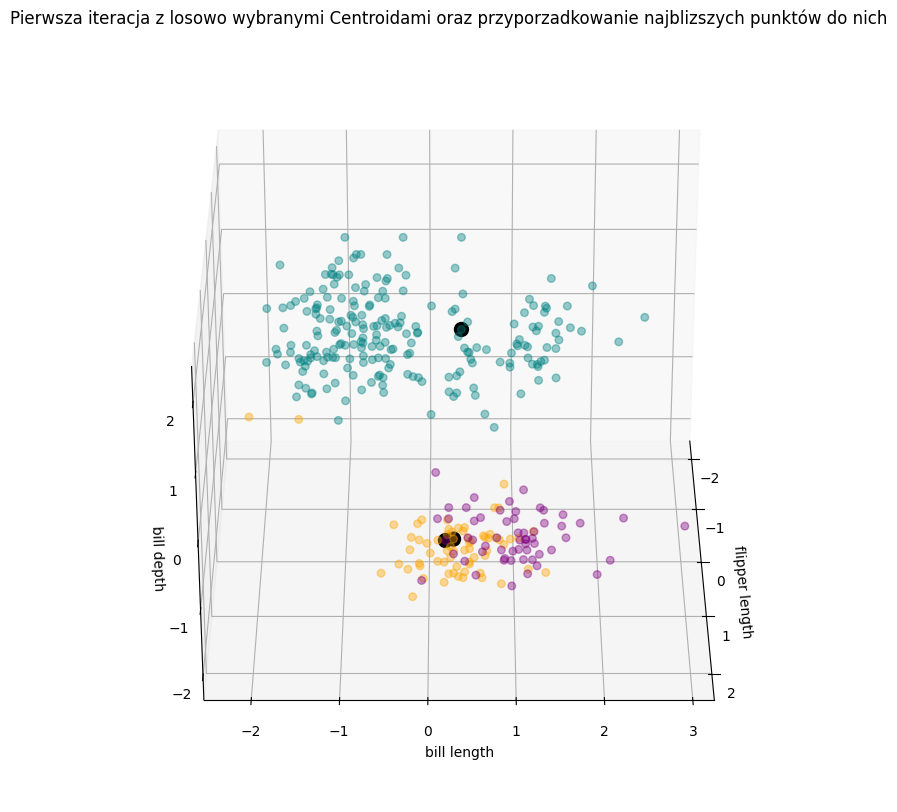

In [5]:
data = data[["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]]

# 3 losowe Centroidy
Centroids = [random.randint(0, len(data["flipper_length_mm"])) for _ in range(3)]


skupiska = {"Centroid1":[], "Centroid2":[], "Centroid3":[]}

for i in range(len(data)):
    distances = []
    for c in Centroids:
        distances.append( math.dist(data.iloc[i], data.iloc[c]) )

    skupiska[f"Centroid{distances.index(min(distances))+1}"].append(i)



for key, index in skupiska.items():
    data.loc[index, "skupisko"] = key

colors = {'Centroid1': 'orange', 'Centroid2': 'purple', 'Centroid3': 'teal'}


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data['flipper_length_mm'], 
    data['bill_length_mm'], 
    data['bill_depth_mm'], 
    c=data['skupisko'].map(colors), 
    s=30,
    alpha=0.4
)
ax.set_xlabel("flipper length")
ax.set_ylabel("bill length")
ax.set_zlabel("bill depth", labelpad=0)
ax.scatter(
    data.iloc[Centroids,0], 
    data.iloc[Centroids,1], 
    data.iloc[Centroids,2], 
    c="black", 
    s=100, 
    alpha=1, 
)
ax.view_init(elev=30,azim=0)

plt.title("Pierwsza iteracja z losowo wybranymi Centroidami oraz przyporzadkowanie najblizszych punktów do nich")
plt.show()

Centroids = [data.iloc[i,[0,1,2]] for i in Centroids]


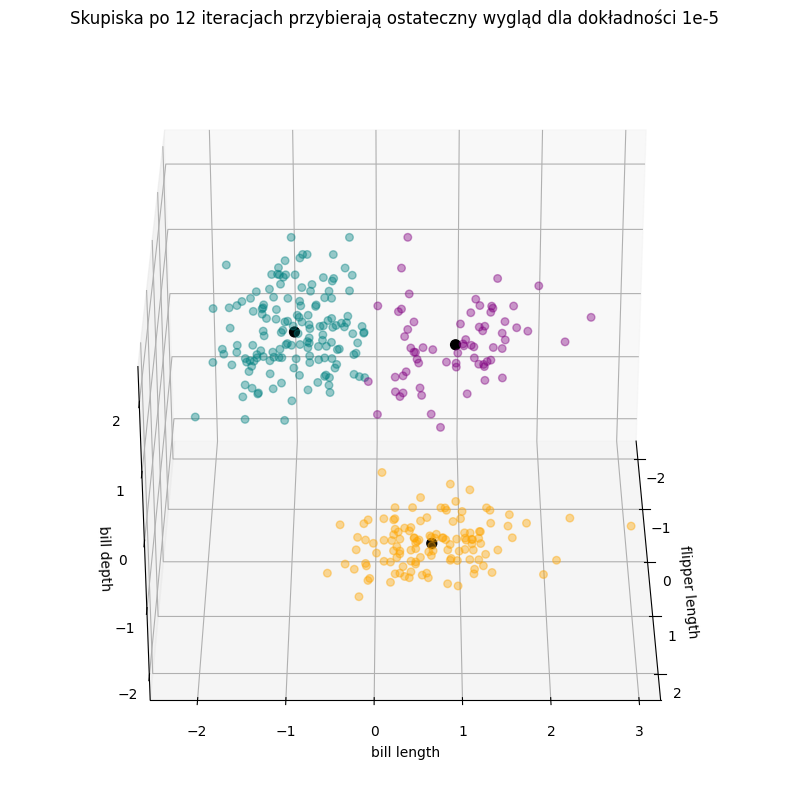

In [6]:
Centroids_cp1 = Centroids.copy()
skupiska_cp1 = skupiska.copy()
data_cp1 = data.copy()

DOKLADNOSC = 1e-5
ITERACJA = 10000

i = 0
while i < ITERACJA:

    # Nowe centroidy
    Centroids_new = [ data.iloc[ Centroid, [0,1,2] ].mean().to_numpy()  for _, Centroid in skupiska.items() ] 

    if all( np.allclose(c_old, c_new, atol=DOKLADNOSC) for c_old, c_new in zip(Centroids, Centroids_new) ):
        break
    else:
        Centroids = Centroids_new


    skupiska = {"Centroid1":[], "Centroid2":[], "Centroid3":[]}

    for t in range(len(data)):
        distances = []
        for c in Centroids:
            distances.append( math.dist(data.iloc[t, [0,1,2]], c) )

        skupiska[f"Centroid{distances.index(min(distances))+1}"].append(t)
    
    i+=1

MAX = i

# Wynik
for key, index in skupiska.items():
    data.loc[index, "skupisko"] = key

colors = {'Centroid1': 'orange', 'Centroid2': 'purple', 'Centroid3': 'teal'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data['flipper_length_mm'], 
    data['bill_length_mm'], 
    data['bill_depth_mm'], 
    c=data['skupisko'].map(colors), 
    s=30,
    alpha=0.4
)
ax.set_xlabel("flipper length")
ax.set_ylabel("bill length")
ax.set_zlabel("bill depth", labelpad=0)

cx, cy, cz = zip(*Centroids)
ax.scatter(
    cx, 
    cy, 
    cz, 
    c="black",
    s=50,
    alpha=1
)
ax.view_init(elev=30,azim=0)

plt.title(f"Skupiska po {i} iteracjach przybierają ostateczny wygląd dla dokładności 1e-5")
plt.show()


In [7]:
def kmeans(ITERACJA):
    Centroids_cp = Centroids_cp1
    skupiska_cp = skupiska_cp1
    data_cp = data_cp1
    i = 0
    
    while i < ITERACJA:

        # Nowe centroidy
        Centroids_new = [ data.iloc[ Centroid, [0,1,2] ].mean().to_numpy()  for _, Centroid in skupiska_cp.items() ] 

        if all( np.allclose(c_old, c_new, atol=DOKLADNOSC) for c_old, c_new in zip(Centroids_cp, Centroids_new) ):
            break
        else:
            Centroids_cp = Centroids_new


        skupiska_cp = {"Centroid1":[], "Centroid2":[], "Centroid3":[]}

        for t in range(len(data)):
            distances = []
            for c in Centroids_cp:
                distances.append( math.dist(data_cp.iloc[t, [0,1,2]], c) )

            skupiska_cp[f"Centroid{distances.index(min(distances))+1}"].append(t)
        
        i+=1


    # Wynik
    for key, index in skupiska_cp.items():
        data_cp.loc[index, "skupisko"] = key

    colors = {'Centroid1': 'orange', 'Centroid2': 'purple', 'Centroid3': 'teal'}

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        data_cp['flipper_length_mm'], 
        data_cp['bill_length_mm'], 
        data_cp['bill_depth_mm'], 
        c=data_cp['skupisko'].map(colors), 
        s=30,
        alpha=0.4
    )
    ax.set_xlabel("flipper length")
    ax.set_ylabel("bill length")
    ax.set_zlabel("bill depth", labelpad=0)

    cx, cy, cz = zip(*Centroids_cp)
    ax.scatter(
        cx, 
        cy, 
        cz, 
        c="black", 
        s=100, 
        alpha=1, 
    )
    ax.view_init(elev=30,azim=0)
    
    plt.title(f"Skupiska po {i} iteracjach")
    plt.show()


Iteracje = widgets.IntSlider(value=0, min=0, max=MAX, continuous_update=True)
widgets.interact(kmeans, ITERACJA=Iteracje)

interactive(children=(IntSlider(value=0, description='ITERACJA', max=12), Output()), _dom_classes=('widget-int…

<function __main__.kmeans(ITERACJA)>

In [8]:
odpowiedniki = {}

# znajduje dominujący gatunek punktów w każdym Centroidzie
for key, points in skupiska.items():
        species = penguins_original["species"].iloc[points]
        
        species_mode = species.mode()[0]
        odpowiedniki[key] = species_mode

print(odpowiedniki)

correct = 0
for i in range(len(penguins_original)):
    if penguins_original["species"].iloc[i] == odpowiedniki[data["skupisko"].iloc[i]]:
        correct += 1

correctnes1 = round(correct/len(penguins_original)*100,2)
print(f"Zgodność z prawdą: {correctnes1} %")

{'Centroid1': 'Gentoo', 'Centroid2': 'Chinstrap', 'Centroid3': 'Adelie'}
Zgodność z prawdą: 96.8 %


TEST dla 4 cech z uwzglednieniem masy żeby sprawdzić czy poprawi to wyniki

In [9]:
data = penguins_original[["flipper_length_mm", "bill_length_mm", "bill_depth_mm", "body_mass_g"]]

# 3 losowe Centroidy
Centroids = [random.randint(0, len(data["flipper_length_mm"])) for _ in range(3)]


skupiska = {"Centroid1":[], "Centroid2":[], "Centroid3":[]}

for i in range(len(data)):
    distances = []
    for c in Centroids:
        distances.append( math.dist(data.iloc[i], data.iloc[c]) )

    skupiska[f"Centroid{distances.index(min(distances))+1}"].append(i)


for key, index in skupiska.items():
    data.loc[index, "skupisko"] = key


Centroids = [data.iloc[i,[0,1,2,3]] for i in Centroids]

In [10]:
ITERACJE = 100000
DOKLADNOSC = 1e-5
i = 0

while i < ITERACJE:

    # Nowe centroidy
    Centroids_new = [ data.iloc[ Centroid, [0,1,2,3] ].mean().to_numpy()  for _, Centroid in skupiska.items() ] 

    if all( np.allclose(c_old, c_new, atol=DOKLADNOSC) for c_old, c_new in zip(Centroids, Centroids_new) ):
        break
    else:
        Centroids = Centroids_new


    skupiska = {"Centroid1":[], "Centroid2":[], "Centroid3":[]}

    for t in range(len(data)):
        distances = []
        for c in Centroids:
            distances.append( math.dist(data.iloc[t, [0,1,2,3]], c) )

        skupiska[f"Centroid{distances.index(min(distances))+1}"].append(t)
    
    i+=1


# Zapis wyników
for key, index in skupiska.items():
    data.loc[index, "skupisko"] = key


In [11]:
odpowiedniki = {}

# znajduje dominujący gatunek punktów w każdym Centroidzie
for key, points in skupiska.items():
        species = penguins_original["species"].iloc[points]
        
        species_mode = species.mode()[0]
        odpowiedniki[key] = species_mode

print(odpowiedniki)

correct = 0
for i in range(len(penguins_original)):
    if penguins_original["species"].iloc[i] == odpowiedniki[data["skupisko"].iloc[i]]:
        correct += 1

correctnes2 = round(correct/len(penguins_original)*100,2)
print(f"Zgodność z prawdą: {correctnes2} %")

{'Centroid1': 'Adelie', 'Centroid2': 'Gentoo', 'Centroid3': 'Chinstrap'}
Zgodność z prawdą: 91.28 %


Poprawność skupisk dla 3 cech (flipper len, bill len, bill depth) - 96.51 %<br>
Poprawność skupisk dla 4 cech (flipper len, bill len, bill depth, body mass) - 79.94 %

Obniżenie jakości dopasowania przy dodaniu masy jest prawdopodobnie spowodowana:
1. Wysoką korelacją flipper len i body mass = 0.87 co przy dodaniu obydwóch cech faworyzuje rozmiar "gabarytowy" ptaka ponad innymi.
2. Im większy wymiar tym więcej szumu